# Assignment 04 — Pedestrian network distance to Sixth Avenue POPS

**Student:** Krishna Goyal  
**Network source:** OpenStreetMap pedestrian network downloaded with OSMnx on August 7, 2026

## Research statement

How much does the pedestrian street network change the apparent distance from the 42 St–Bryant Park subway entrance to fifteen outdoor POPS along Sixth Avenue?

The straight-line measure treats the city as an unobstructed plane. The network measure follows mapped walkable edges. Comparing them reveals how blocks, crossings, plaza placement, and network topology shape actual access.

In [1]:
%matplotlib inline
from pathlib import Path
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

def first_existing(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these paths exist: {candidates}")

## 1. Load and define the network

The cached GraphML covers the Midtown study corridor and a surrounding margin. Nodes represent mapped intersections or geometry changes; edges represent walkable street and path segments. Edge `length` in meters is the weight used for shortest paths.

In [2]:
graph_path = first_existing(["midtown_pops_walk_network.graphml", "content/Assignments/04_pops_network_distance/midtown_pops_walk_network.graphml"])
places_path = first_existing(["pops_network_destinations.geojson", "content/Assignments/04_pops_network_distance/pops_network_destinations.geojson"])

graph = ox.load_graphml(graph_path)
places = gpd.read_file(places_path)
nodes, edges = ox.graph_to_gdfs(graph)

print(f"Network nodes: {len(nodes):,}")
print(f"Directed edges: {len(edges):,}")
print(f"Destinations: {(places['role'] == 'destination POPS').sum()}")
display(places.drop(columns="geometry").head())

Network nodes: 6,453
Directed edges: 20,174
Destinations: 15


,id,name,role,pops_number,provision_score,score_band,source
0,origin_bryant_park,42 St–Bryant Park station entrance,origin,NaN,NaN,NaN,approximate mapped entrance at Sixth Avenue an...
1,M050060,1095 SIXTH AVENUE,destination POPS,M050060,100.0,Extensive,NaN
2,M050057,1114 SIXTH AVENUE,destination POPS,M050057,100.0,Extensive,NaN
3,M050055,1133 SIXTH AVENUE,destination POPS,M050055,57.0,Moderate,NaN
4,M050054,1155 SIXTH AVENUE,destination POPS,M050054,86.0,Extensive,NaN


## 2. Locate the origin and destinations

The origin is an approximate entrance to the 42 St–Bryant Park B/D/F/M station at Sixth Avenue and West 42nd Street. The destinations are the same fifteen POPS used in the final project. Points must be snapped to nearby network nodes before routing.

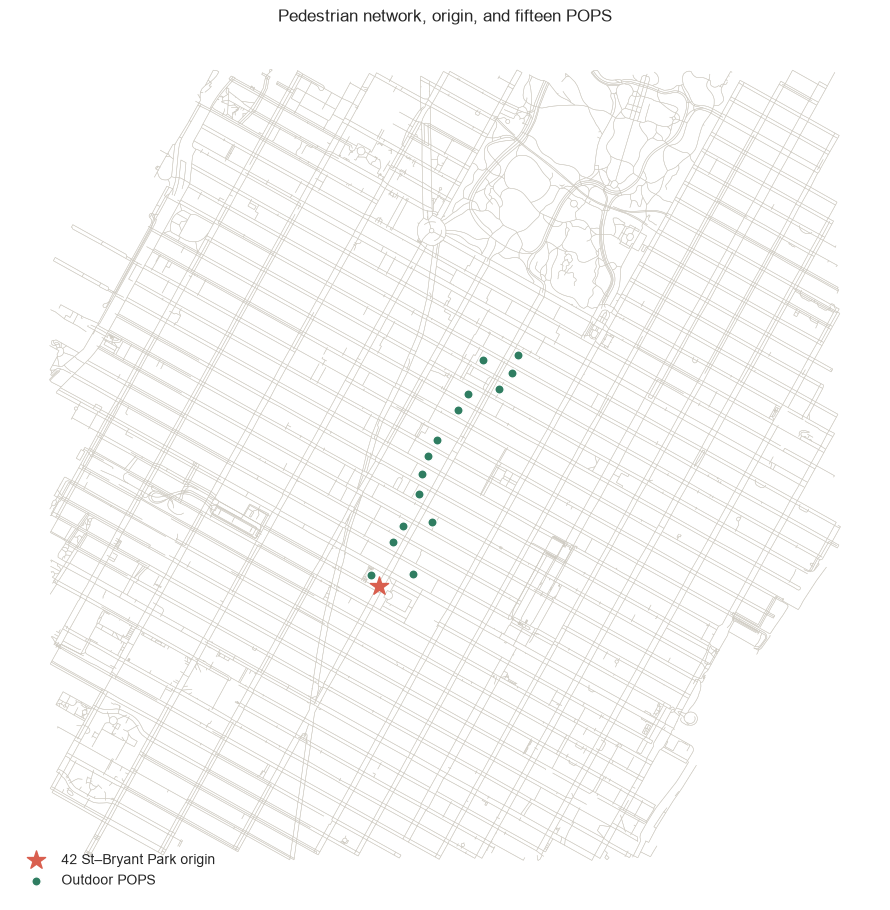

In [3]:
fig, ax = plt.subplots(figsize=(9, 10))
edges.plot(ax=ax, color="#d0ccc3", linewidth=0.35)
places.loc[places["role"].eq("origin")].plot(ax=ax, color="#d95f4f", marker="*", markersize=190, label="42 St–Bryant Park origin", zorder=3)
places.loc[places["role"].eq("destination POPS")].plot(ax=ax, color="#2f7d61", markersize=45, edgecolor="white", label="Outdoor POPS", zorder=3)
ax.set_title("Pedestrian network, origin, and fifteen POPS")
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 3. Calculate Euclidean proxy and network distance

The lower-bound comparison uses haversine distance between coordinates. Network distance snaps each point to the nearest graph node, calculates the shortest path weighted by edge length, and adds short straight-line connectors between the original points and their snapped nodes. The detour factor is `network distance ÷ straight-line distance`.

In [4]:
def haversine_m(lon1, lat1, lon2, lat2):
    radius_m = 6_371_008.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * radius_m * math.asin(math.sqrt(a))

node_x = nodes.geometry.x.to_numpy()
node_y = nodes.geometry.y.to_numpy()
node_ids = nodes.index.to_numpy()
mean_lat = math.radians(float(node_y.mean()))

def nearest_node(lon, lat):
    distance_proxy = ((node_x - lon) * math.cos(mean_lat)) ** 2 + (node_y - lat) ** 2
    return node_ids[int(np.argmin(distance_proxy))]

origin = places.loc[places["role"].eq("origin")].iloc[0]
origin_lon, origin_lat = origin.geometry.x, origin.geometry.y
origin_node = nearest_node(origin_lon, origin_lat)
origin_node_geom = nodes.loc[origin_node].geometry
origin_connector_m = haversine_m(origin_lon, origin_lat, origin_node_geom.x, origin_node_geom.y)

records = []
routes = {}
for _, destination in places.loc[places["role"].eq("destination POPS")].iterrows():
    lon, lat = destination.geometry.x, destination.geometry.y
    destination_node = nearest_node(lon, lat)
    route = nx.shortest_path(graph, origin_node, destination_node, weight="length")
    route_m = nx.shortest_path_length(graph, origin_node, destination_node, weight="length")
    destination_node_geom = nodes.loc[destination_node].geometry
    destination_connector_m = haversine_m(lon, lat, destination_node_geom.x, destination_node_geom.y)
    connector_m = origin_connector_m + destination_connector_m
    network_m = route_m + connector_m
    straight_m = haversine_m(origin_lon, origin_lat, lon, lat)
    routes[destination["pops_number"]] = route
    records.append({
        "pops_number": destination["pops_number"], "address": destination["name"],
        "provision_score": destination["provision_score"], "straight_line_m": straight_m,
        "network_m": network_m, "snap_connector_m": connector_m, "added_m": network_m - straight_m,
        "detour_ratio": network_m / straight_m,
    })

results = pd.DataFrame(records).set_index("pops_number").sort_values("network_m")
display(results.round({"straight_line_m": 0, "network_m": 0, "added_m": 0, "detour_ratio": 2}))
results.to_csv("pops_network_distance_results.csv")

,address,provision_score,straight_line_m,network_m,snap_connector_m,added_m,detour_ratio
pops_number,,,,,,,
M050060,1095 SIXTH AVENUE,100.0,58.0,110.0,20.993508,52.0,1.88
M050055,1133 SIXTH AVENUE,57.0,197.0,294.0,59.213321,97.0,1.49
M050057,1114 SIXTH AVENUE,100.0,152.0,325.0,58.094738,173.0,2.14
M050054,1155 SIXTH AVENUE,86.0,276.0,435.0,51.592568,159.0,1.58
M050048,1185 SIXTH AVENUE,71.0,429.0,516.0,51.395094,87.0,1.20
M050052,1166 SIXTH AVENUE,100.0,356.0,526.0,47.968158,170.0,1.48
M050047,1211 SIXTH AVENUE,14.0,512.0,589.0,60.101605,78.0,1.15
M050043,1221 SIXTH AVENUE,86.0,596.0,726.0,68.896017,130.0,1.22
M050042,1251 SIXTH AVENUE,0.0,671.0,764.0,91.480344,93.0,1.14


## 4. Compare distance measures

The paired bars show absolute differences. The detour-factor chart shows proportional differences, which prevents long trips from automatically appearing to have the largest effect.

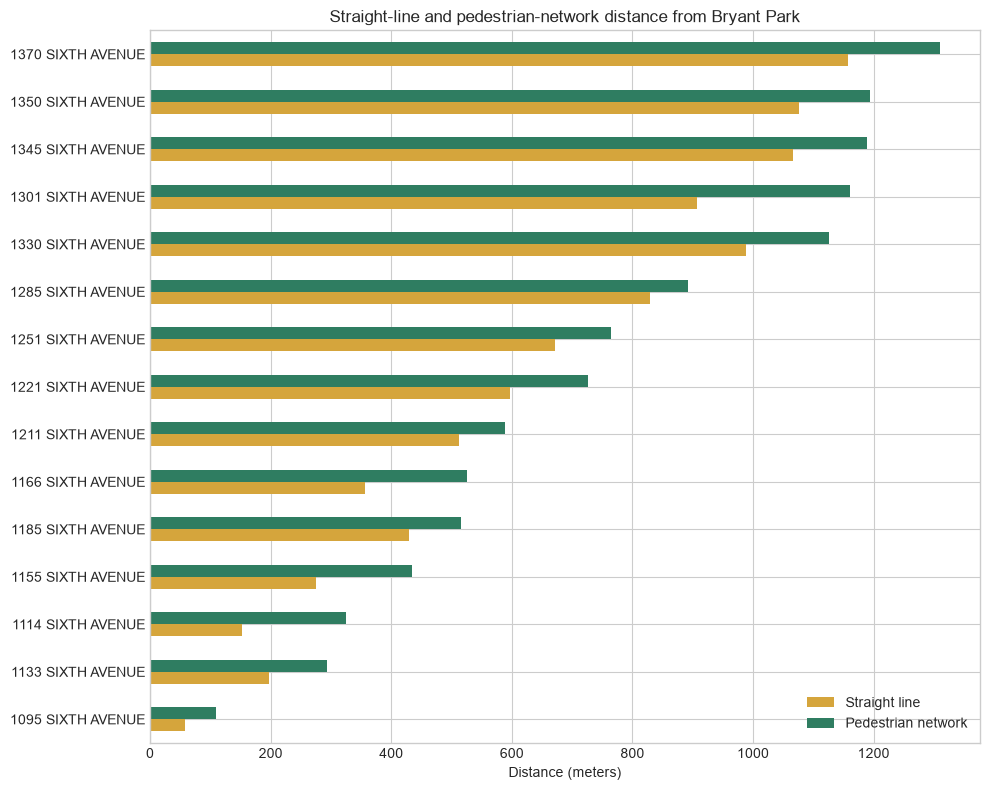

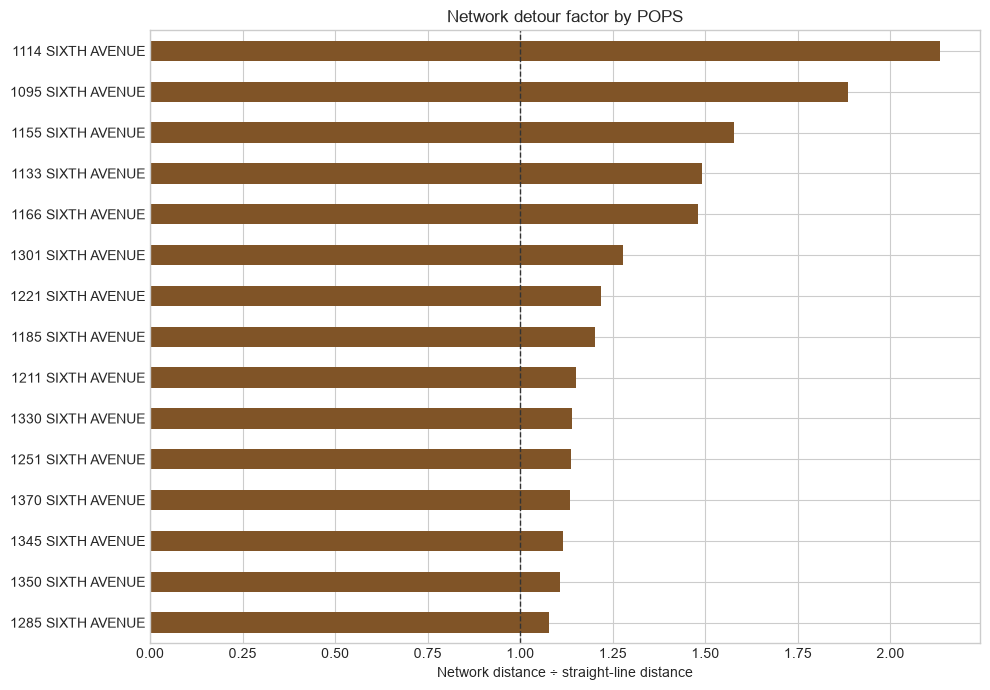

In [5]:
comparison = results.set_index("address")[["straight_line_m", "network_m"]].rename(columns={"straight_line_m": "Straight line", "network_m": "Pedestrian network"})
ax = comparison.sort_values("Pedestrian network").plot(kind="barh", figsize=(10, 8), color=["#d5a53c", "#2f7d61"])
ax.set(title="Straight-line and pedestrian-network distance from Bryant Park", xlabel="Distance (meters)", ylabel="")
plt.tight_layout()
plt.show()

detour = results.set_index("address")["detour_ratio"].sort_values()
ax = detour.plot(kind="barh", figsize=(10, 7), color="#805427")
ax.axvline(1, color="#333333", linestyle="--", linewidth=1)
ax.set(title="Network detour factor by POPS", xlabel="Network distance ÷ straight-line distance", ylabel="")
plt.tight_layout()
plt.show()

## 5. Map the shortest paths

Every colored line follows mapped walkable edges. Overlapping routes reveal the shared Sixth Avenue spine, while local deviations show where the network reaches a plaza from the origin.

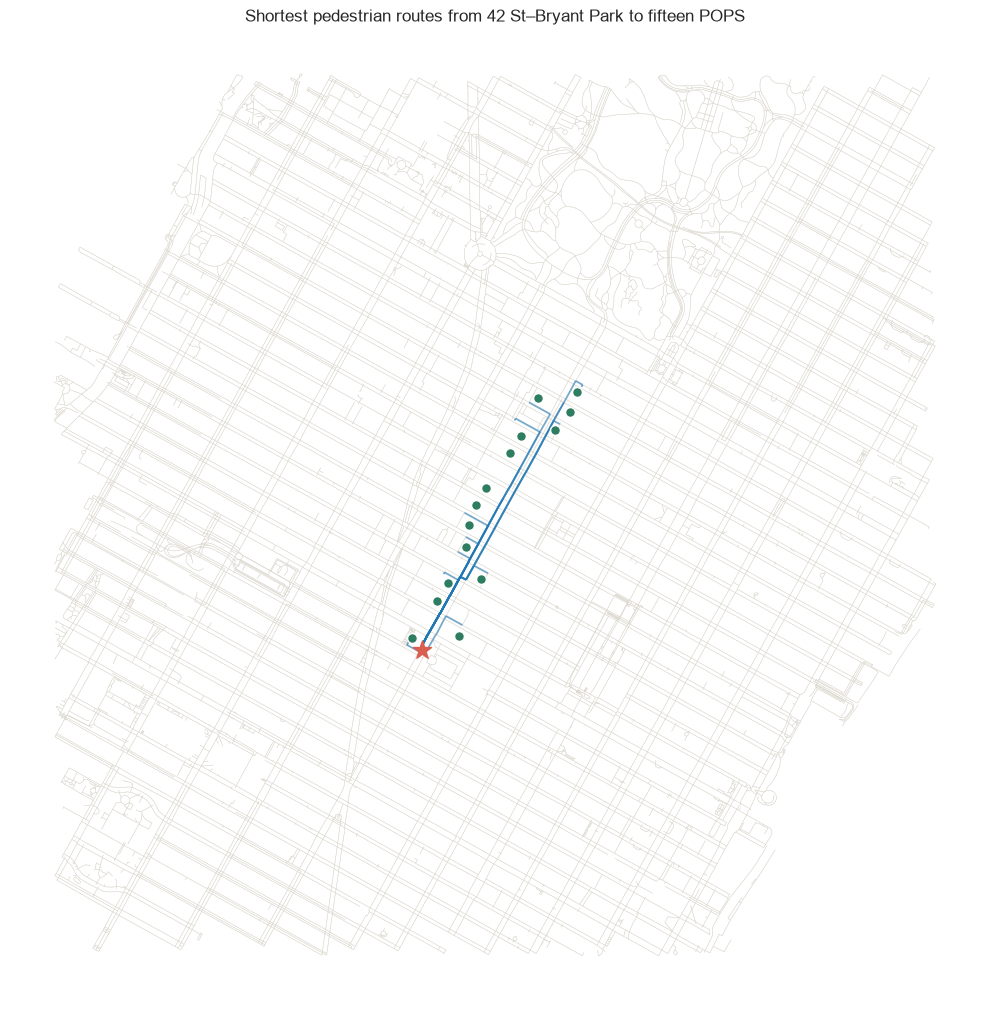

Largest proportional detour: 1114 SIXTH AVENUE (2.14×)
Smallest proportional detour: 1285 SIXTH AVENUE (1.08×)


In [6]:
fig, ax = plt.subplots(figsize=(10, 11))
edges.plot(ax=ax, color="#ddd9d0", linewidth=0.3, zorder=1)
for pops_number, route in routes.items():
    route_gdf = ox.routing.route_to_gdf(graph, route, weight="length")
    route_gdf.plot(ax=ax, linewidth=1.35, alpha=0.55, zorder=2)
places.loc[places["role"].eq("destination POPS")].plot(ax=ax, color="#2f7d61", edgecolor="white", markersize=50, zorder=3)
places.loc[places["role"].eq("origin")].plot(ax=ax, color="#d95f4f", marker="*", markersize=190, zorder=4)
ax.set_title("Shortest pedestrian routes from 42 St–Bryant Park to fifteen POPS")
ax.set_axis_off()
plt.tight_layout()
plt.show()

largest = results["detour_ratio"].idxmax()
smallest = results["detour_ratio"].idxmin()
print(f"Largest proportional detour: {results.loc[largest, 'address']} ({results.loc[largest, 'detour_ratio']:.2f}×)")
print(f"Smallest proportional detour: {results.loc[smallest, 'address']} ({results.loc[smallest, 'detour_ratio']:.2f}×)")

## Reflection

Straight-line distance is a useful lower bound, but experientially it assumes that a person can pass through buildings and cross streets anywhere. The network measure introduces mapped intersections, sidewalks, crossings, and route continuity. Along a regular Manhattan grid the two measures often track one another, yet even a modest proportional detour matters when access depends on a specific corner or crossing.

The network still simplifies experience. Edge length does not encode wait time at signals, crowding, construction, curb ramps, stairs, perceived safety, weather, or whether the mapped plaza entrance is the entrance a person would actually use. Straight connector segments reduce—but do not eliminate—the error introduced by snapping a plaza point to the street network. The analysis therefore measures **mapped pedestrian-network distance**, not universal accessibility or travel time.